# ❤️ Heart Disease Prediction

**Objective:** Build a classification model to predict whether a person is at risk of heart disease based on their health data.

**Dataset:** Heart Disease UCI Dataset (Kaggle / UCI ML Repository)

**Models Used:** Logistic Regression, Decision Tree

**Evaluation Metrics:** Accuracy, ROC-AUC, Confusion Matrix

---
## 1. Import Libraries
Importing all required libraries for data handling, visualization, and machine learning.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(" All libraries imported successfully.")

 All libraries imported successfully.


---
## 2. Load the Dataset

The Heart Disease UCI dataset contains **303 patient records** with 14 features including age, sex, chest pain type, cholesterol, and more.

> **Download:** https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci  
> Save the file as `heart.csv` in the same folder as this notebook.

**Column Descriptions:**

| Column | Description |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Max heart rate achieved |
| `exang` | Exercise-induced angina (1=yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) |
| `thal` | Thalassemia type |
| `condition` | **Target** - 0 = No Disease, 1 = Disease |


In [4]:
df = pd.read_csv('heart.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (297, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


---
## 3. Exploratory Data Analysis (EDA)

Before building any model, explore the structure, distributions, and relationships in the data.


### 3.1 Basic Info and Summary Statistics

In [5]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
print("=== Descriptive Statistics ===")
df.describe().round(2)


=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,2.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,0.60,0.68,0.84,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.00,1.00,2.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,0.00,0.00
75%,61.00,1.00,3.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,2.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,1.00


In [7]:
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


=== Missing Values ===
No missing values found!


### 3.2 Target Variable Distribution

Check how many patients have heart disease vs not.


No Disease   : 160 patients (53.9%)
Heart Disease: 137 patients (46.1%)


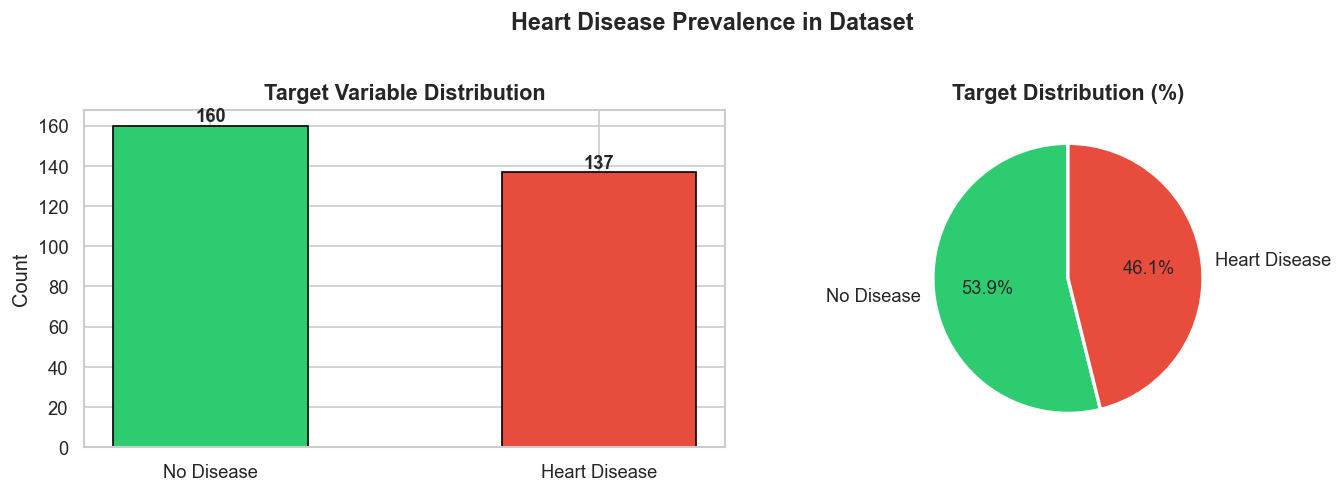

In [18]:
target_col = 'condition' if 'condition' in df.columns else 'target'
counts = df[target_col].value_counts()
labels = ['No Disease', 'Heart Disease']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease Prevalence in Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

print(f"No Disease   : {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease: {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)")

plt.savefig('hd_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Feature Distributions (Histograms)

Histograms help us understand how each numerical feature is distributed across the dataset.


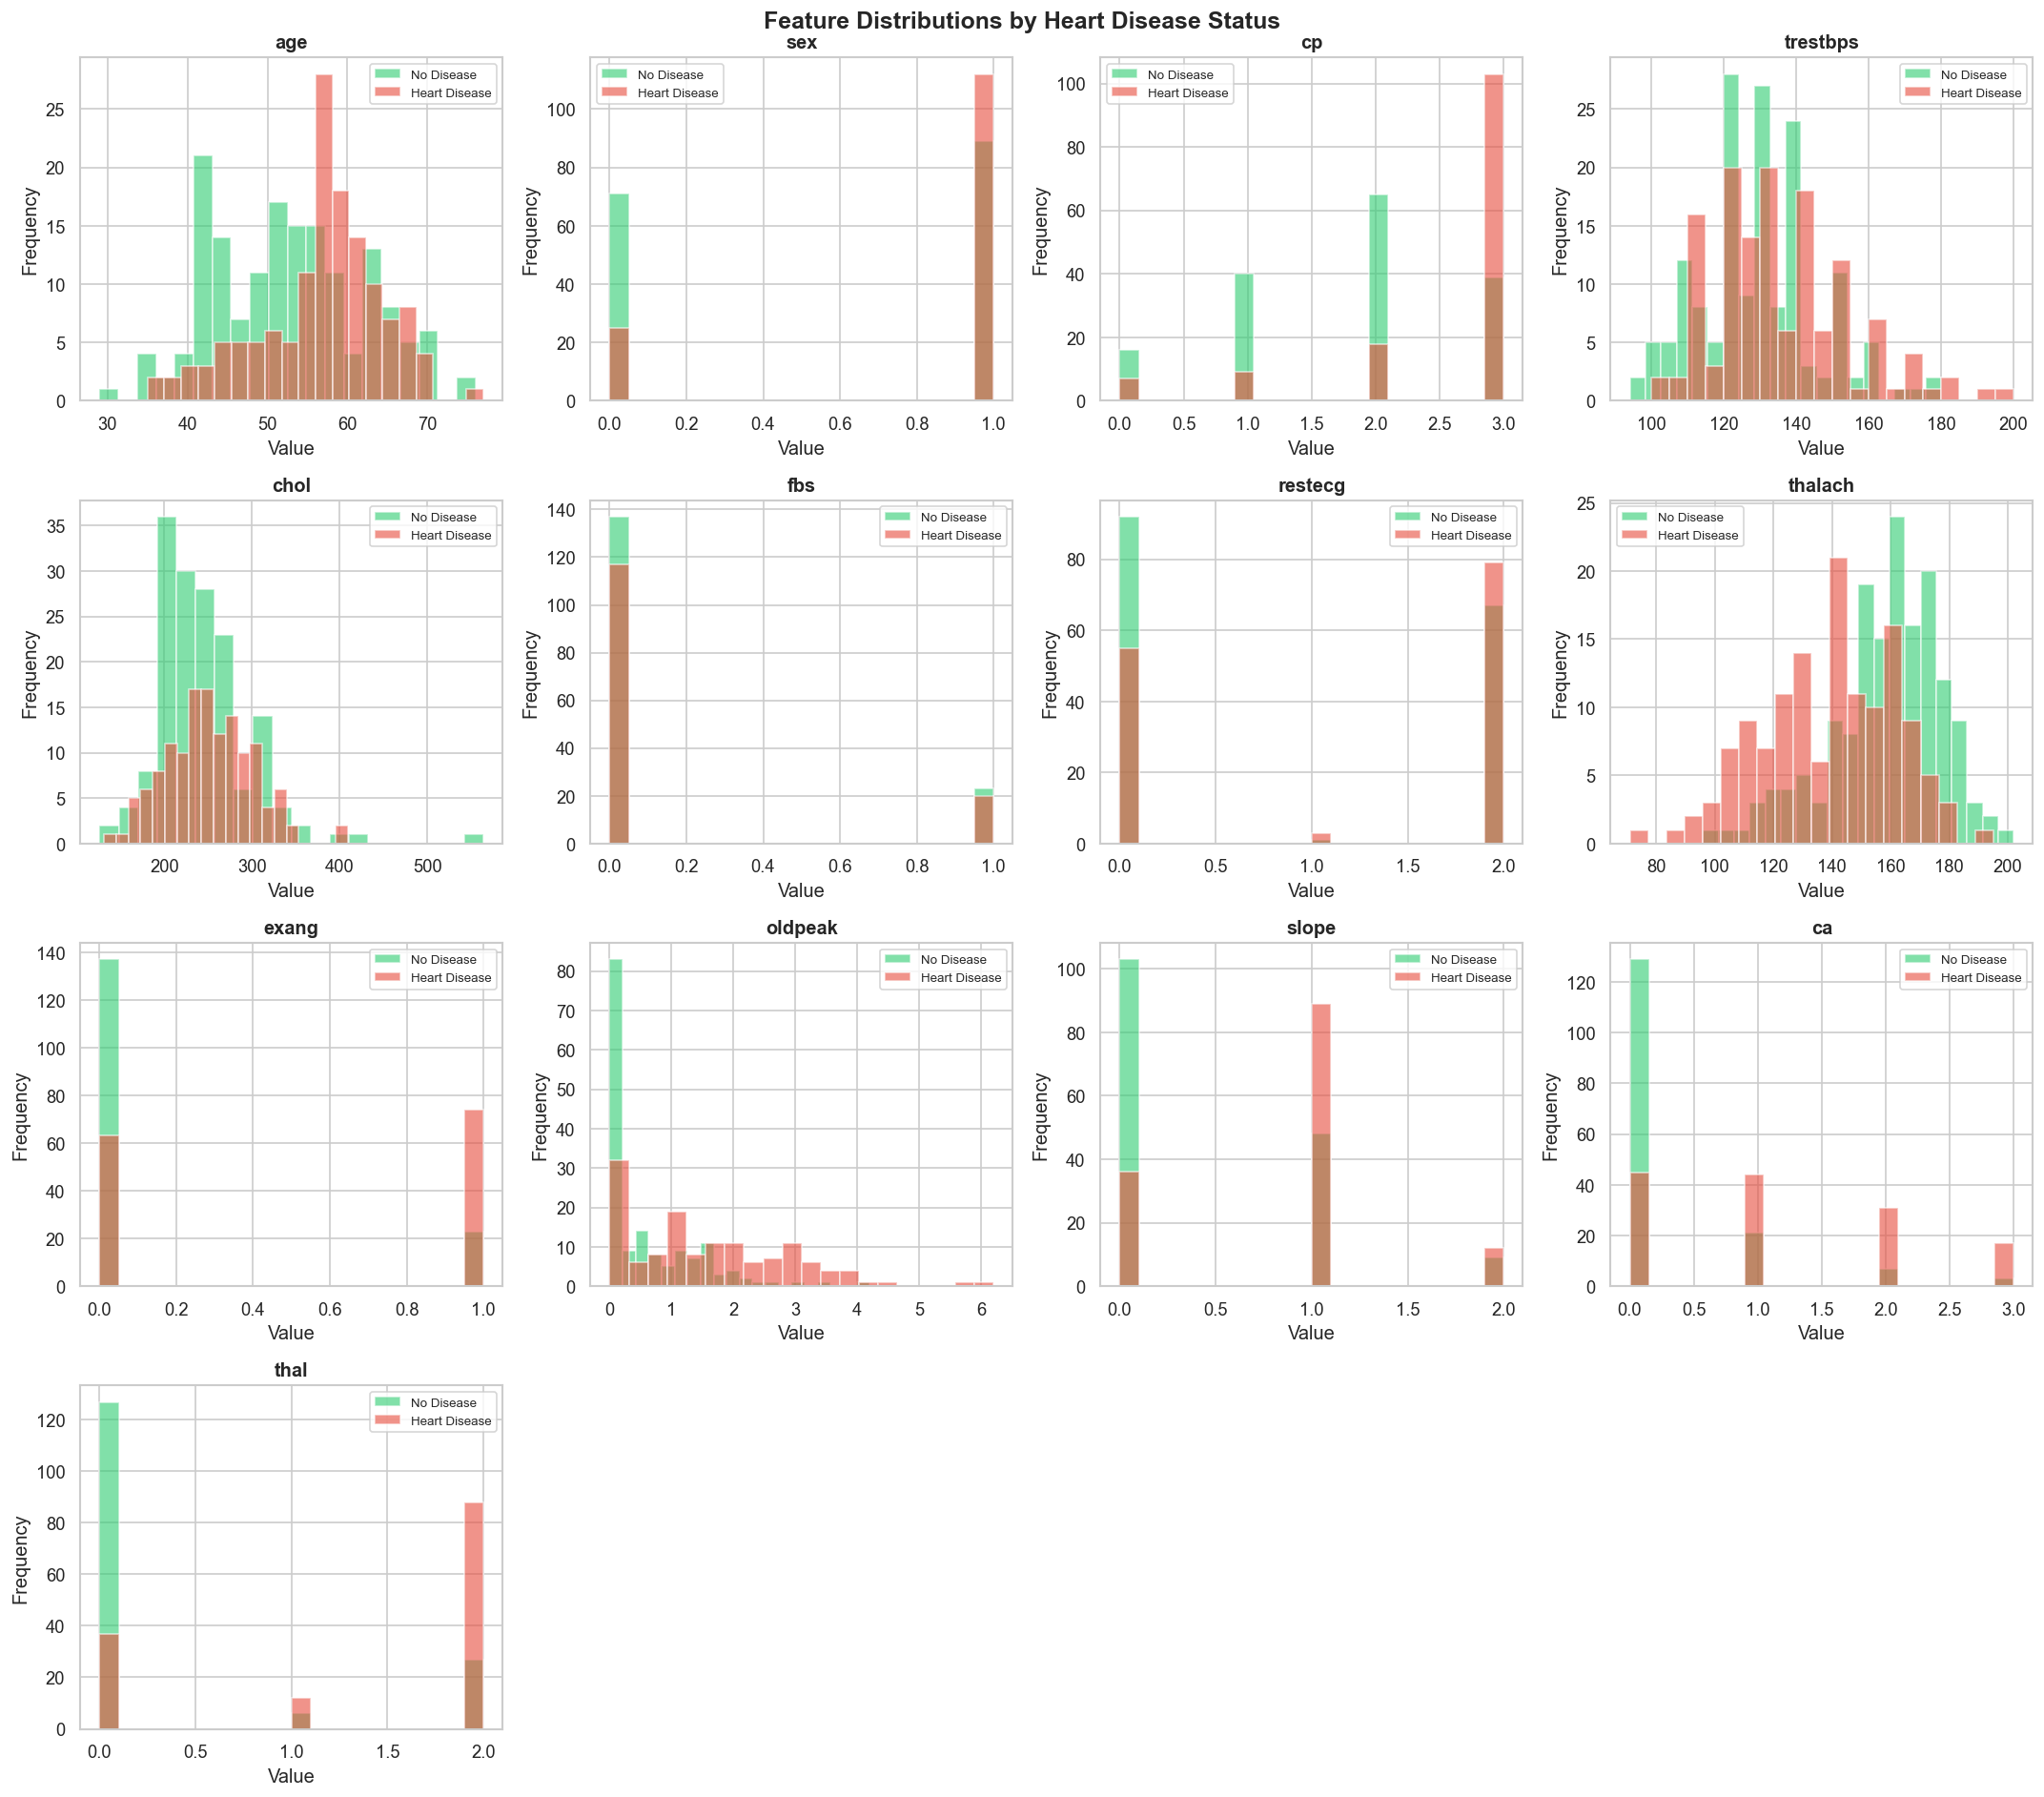

In [17]:
target_col = 'condition' if 'condition' in df.columns else 'target'
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target_col]

ncols = 4
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[df[target_col]==0][col], alpha=0.6, label='No Disease',  color='#2ecc71', edgecolor='white', bins=20)
    ax.hist(df[df[target_col]==1][col], alpha=0.6, label='Heart Disease', color='#e74c3c', edgecolor='white', bins=20)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_02_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Correlation Heatmap

The heatmap reveals which features are strongly correlated with the target and with each other.



Top correlations with target:
thal        0.520516
ca          0.463189
oldpeak     0.424052
thalach     0.423817
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167


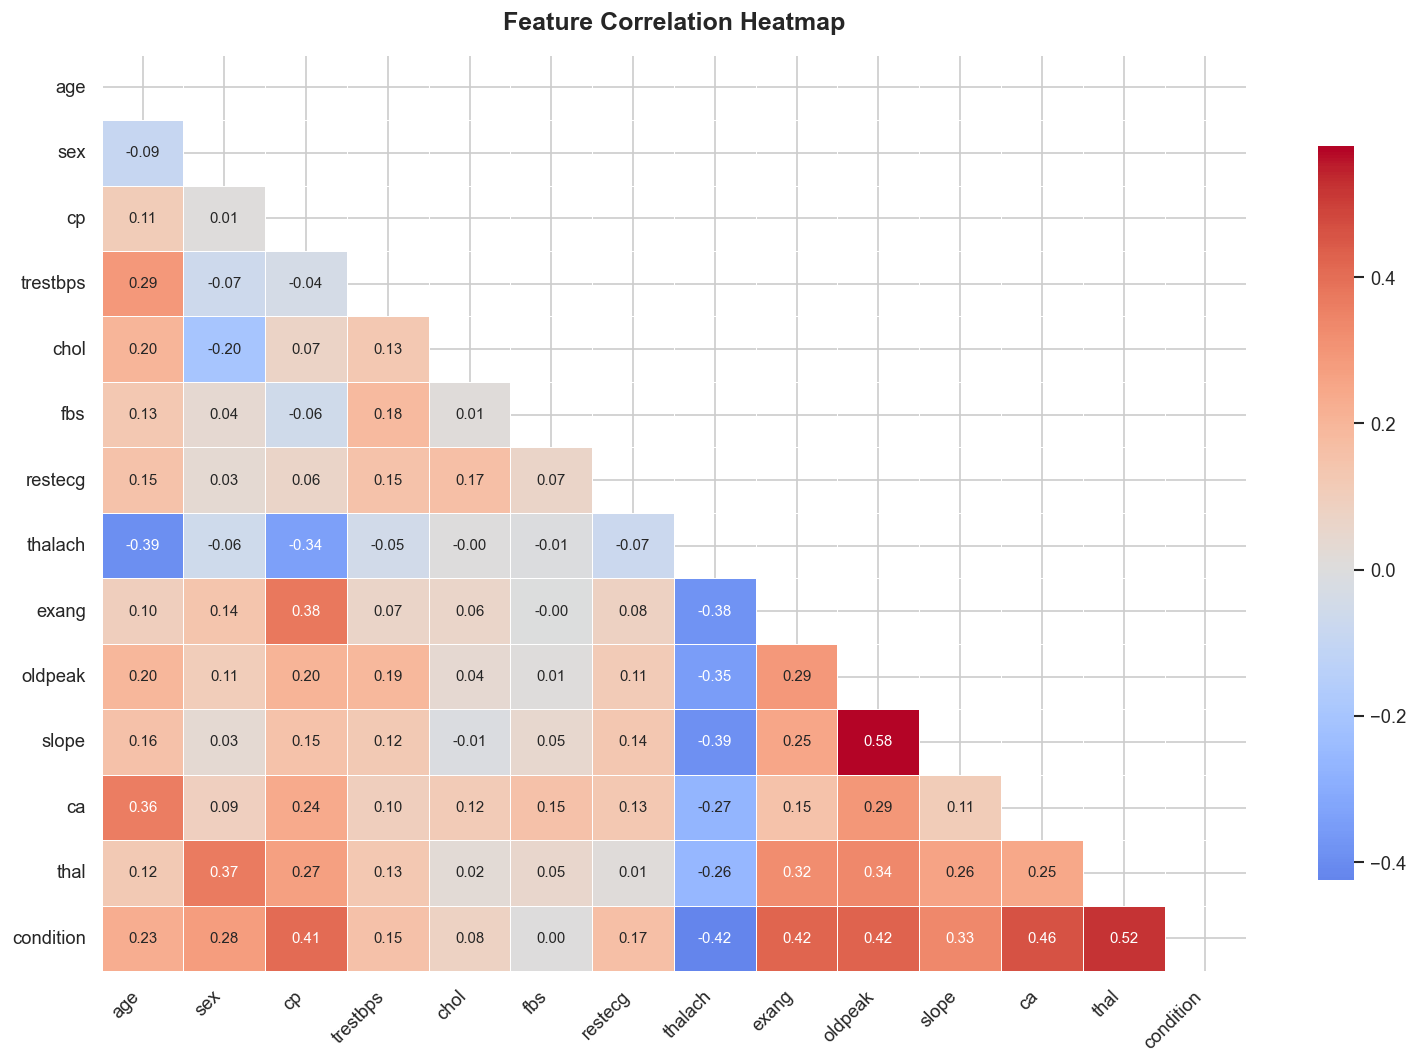

In [19]:
target_col = 'condition' if 'condition' in df.columns else 'target'

plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

print("\nTop correlations with target:")
print(corr[target_col].drop(target_col).abs().sort_values(ascending=False).to_string())

plt.savefig('hd_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Box Plots - Identifying Outliers

Box plots show the spread of values and highlight outliers (points beyond the whiskers).


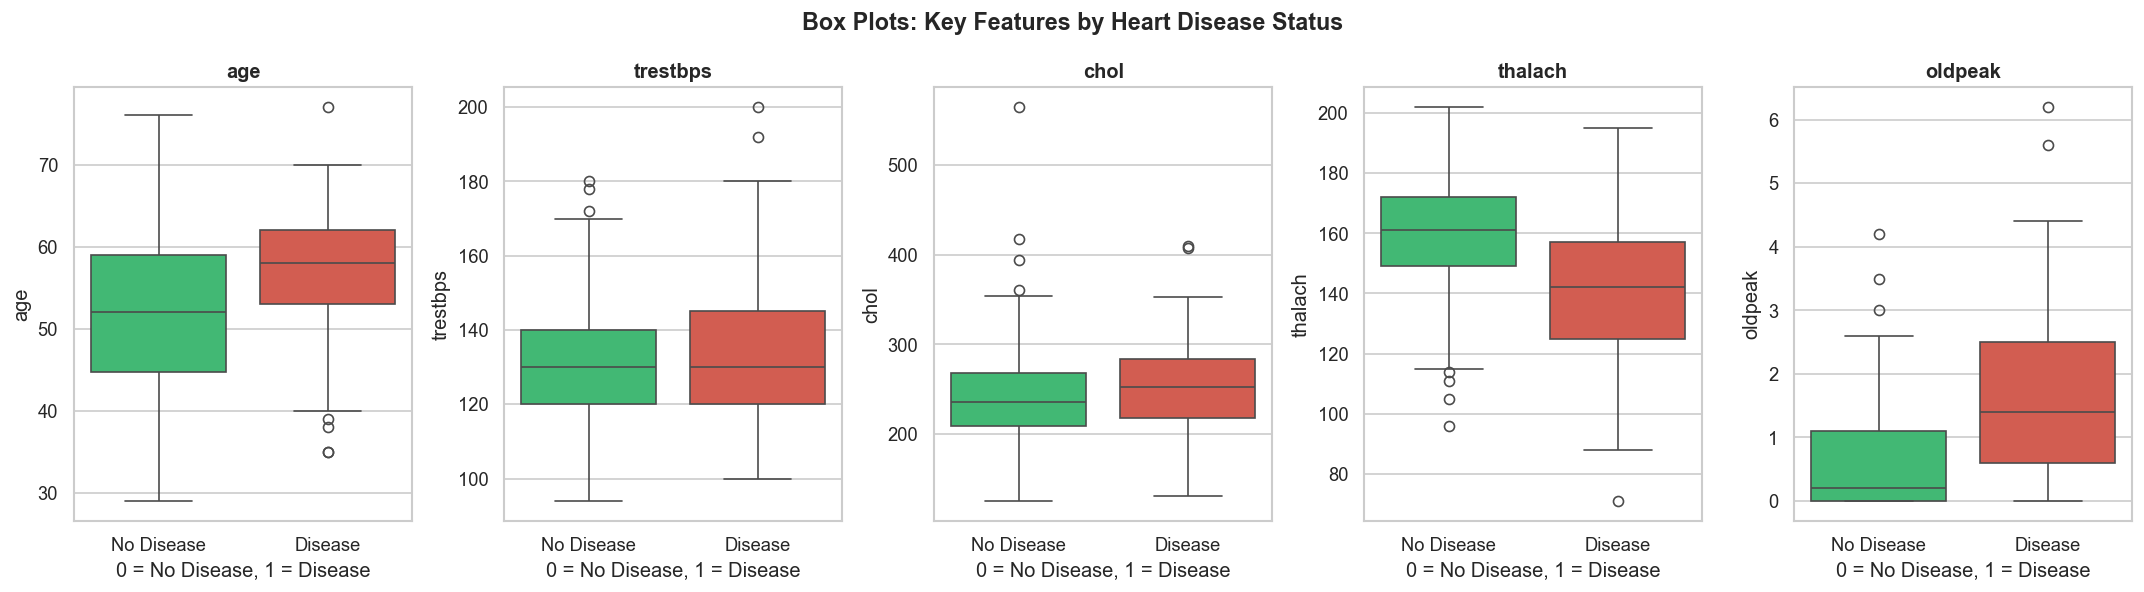

In [16]:
target_col = 'condition' if 'condition' in df.columns else 'target'
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(cont_cols), figsize=(18, 5))

for i, col in enumerate(cont_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i],
                palette={'0': '#2ecc71', '1': '#e74c3c'})
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('0 = No Disease, 1 = Disease')
    axes[i].set_xticklabels(['No Disease', 'Disease'])

plt.suptitle('Box Plots: Key Features by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hd_04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Categorical Features vs Target

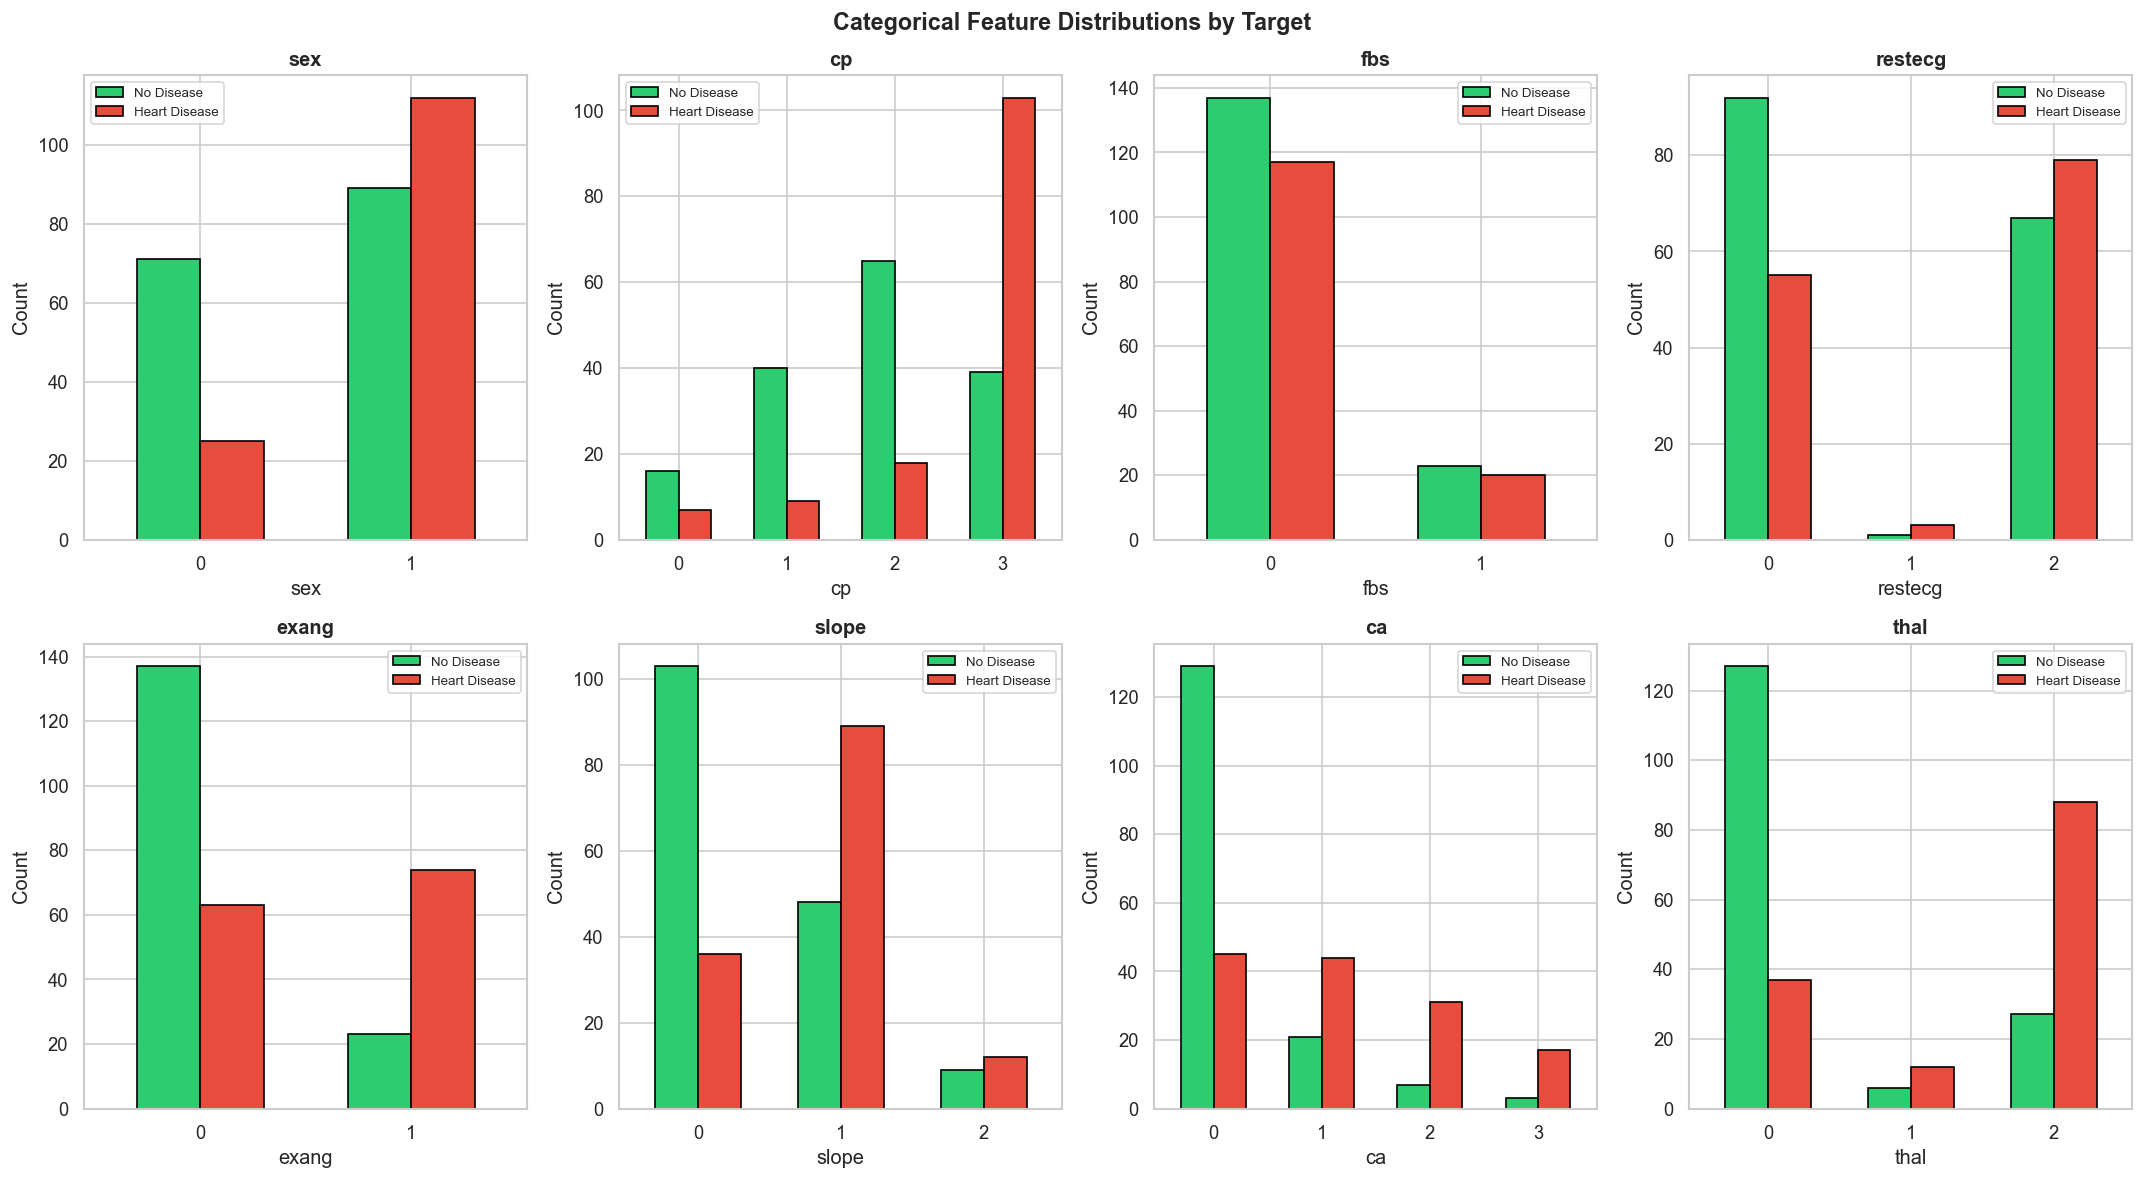

In [20]:
target_col = 'condition' if 'condition' in df.columns else 'target'
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, target_col]).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_05_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Data Preprocessing

Prepare the data for model training. This section shows **before and after** comparisons so we can see the effect of each step:

1. Separate features (X) and target (y)
2. Split into training and test sets (80/20, stratified)
3. Scale features using **StandardScaler** - transforms each feature to have mean ≈ 0 and std ≈ 1


### 4.1 Before Preprocessing - Raw Feature Statistics

In [21]:
target_col = 'condition' if 'condition' in df.columns else 'target'

X = df.drop(columns=[target_col])
y = df[target_col]

print("=== RAW Feature Statistics (Before Scaling) ===\n")
raw_stats = X.describe().loc[['mean', 'std', 'min', 'max']].T
raw_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(raw_stats.round(2).to_string())


=== RAW Feature Statistics (Before Scaling) ===

            Mean  Std Dev    Min    Max
age        54.54     9.05   29.0   77.0
sex         0.68     0.47    0.0    1.0
cp          2.16     0.96    0.0    3.0
trestbps  131.69    17.76   94.0  200.0
chol      247.35    52.00  126.0  564.0
fbs         0.14     0.35    0.0    1.0
restecg     1.00     0.99    0.0    2.0
thalach   149.60    22.94   71.0  202.0
exang       0.33     0.47    0.0    1.0
oldpeak     1.06     1.17    0.0    6.2
slope       0.60     0.62    0.0    2.0
ca          0.68     0.94    0.0    3.0
thal        0.84     0.96    0.0    2.0


The huge scale differences - `chol` (cholesterol) values are in the 100s while `fbs` is just 0 or 1. This causes issues for models like Logistic Regression that are sensitive to feature magnitude. StandardScaler fixes this.


### 4.2 Visualizing Raw Feature Scales (Before Scaling)

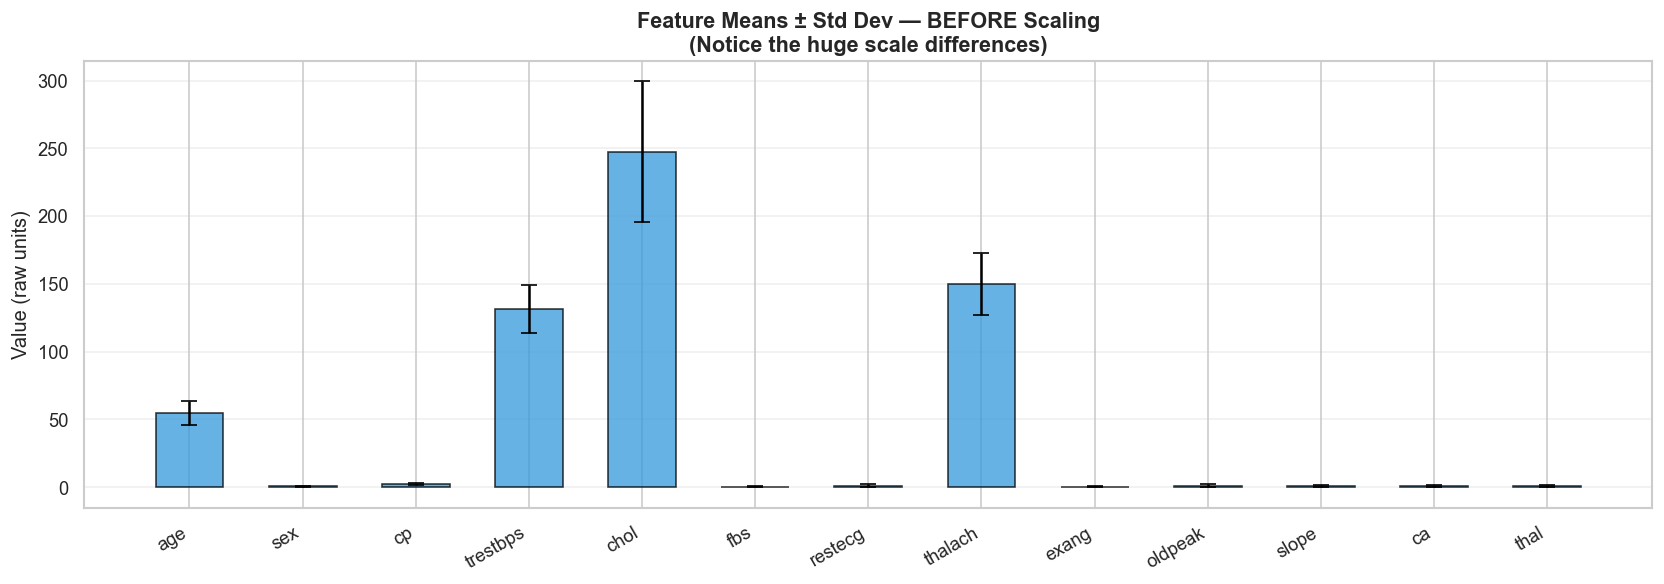

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

# Show mean ± std for each raw feature
means = X.mean()
stds  = X.std()

x_pos = np.arange(len(X.columns))
bars = ax.bar(x_pos, means.values, yerr=stds.values, color='#3498db',
              alpha=0.75, edgecolor='black', capsize=5, width=0.6)

ax.set_xticks(x_pos)
ax.set_xticklabels(X.columns, rotation=30, ha='right')
ax.set_ylabel('Value (raw units)', fontsize=12)
ax.set_title('Feature Means ± Std Dev — BEFORE Scaling\n(Notice the huge scale differences)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('hd_06_before_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nClass distribution — Training set:")
print(y_train.value_counts().rename({0:'No Disease', 1:'Heart Disease'}).to_string())
print(f"\nClass distribution — Test set:")
print(y_test.value_counts().rename({0:'No Disease', 1:'Heart Disease'}).to_string())


Training set : 237 samples
Test set     : 60 samples

Class distribution — Training set:
condition
No Disease       128
Heart Disease    109

Class distribution — Test set:
condition
No Disease       32
Heart Disease    28


### 4.4 Apply StandardScaler

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("=== SCALED Feature Statistics (After Scaling) ===\n")
scaled_stats = X_train_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].T
scaled_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(scaled_stats.round(4).to_string())
print("\n All features now have mean ≈ 0 and std ≈ 1")


=== SCALED Feature Statistics (After Scaling) ===

          Mean  Std Dev     Min     Max
age       -0.0   1.0021 -2.9260  2.4767
sex        0.0   1.0021 -1.4989  0.6672
cp        -0.0   1.0021 -2.1977  0.8904
trestbps  -0.0   1.0021 -2.1330  3.8368
chol       0.0   1.0021 -2.3642  6.1396
fbs       -0.0   1.0021 -0.4093  2.4435
restecg    0.0   1.0021 -0.9812  1.0322
thalach    0.0   1.0021 -3.4978  2.3372
exang      0.0   1.0021 -0.7004  1.4277
oldpeak    0.0   1.0021 -0.8912  4.2808
slope      0.0   1.0021 -0.9445  2.1863
ca         0.0   1.0021 -0.7244  2.3415
thal      -0.0   1.0021 -0.8990  1.2002

 All features now have mean ≈ 0 and std ≈ 1


### 4.5 Before vs After Scaling - Visual Comparison

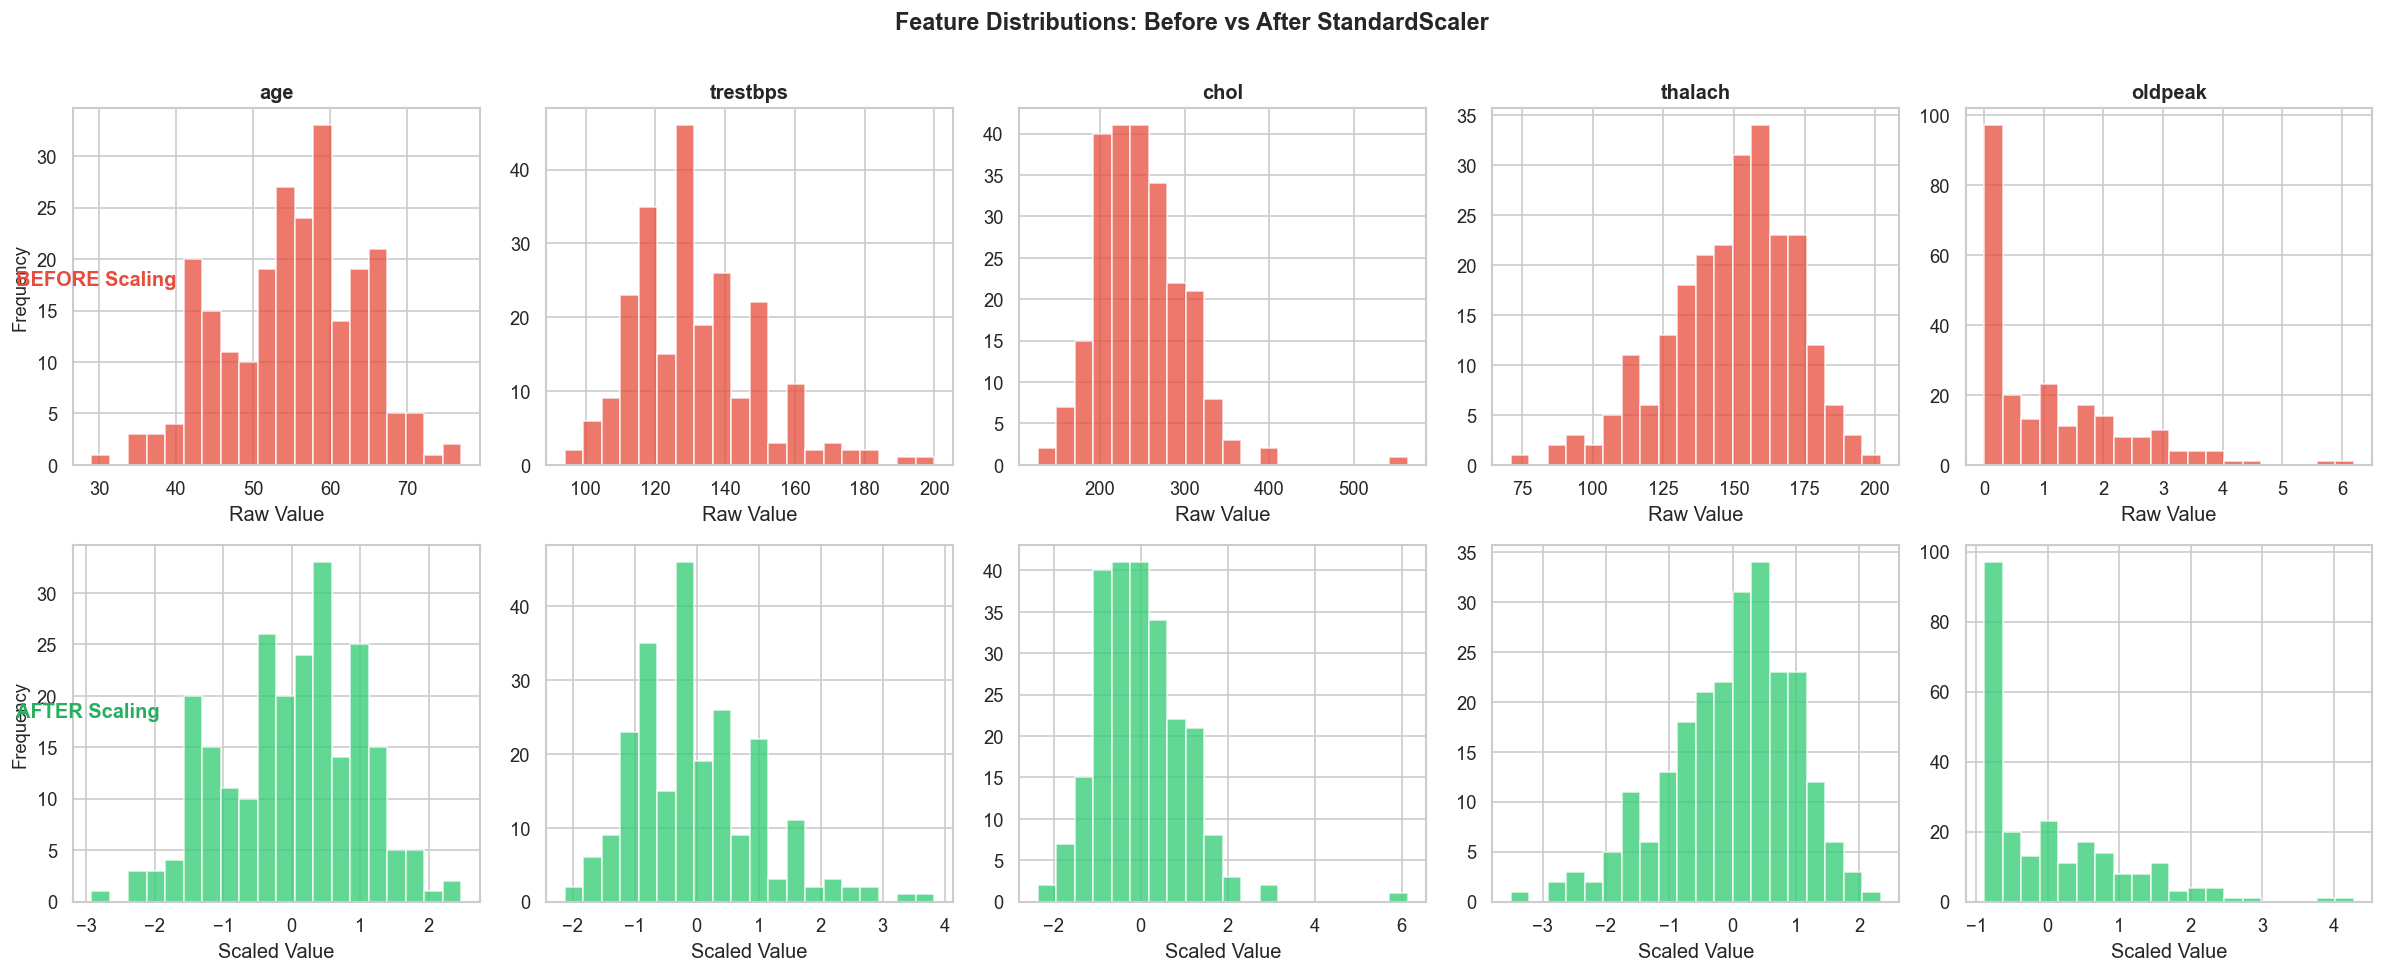

In [27]:
# Pick 5 continuous features to compare
compare_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(compare_cols):
    # BEFORE
    axes[0, i].hist(X_train[col], bins=20, color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_xlabel('Raw Value')
    if i == 0:
        axes[0, i].set_ylabel('Frequency', fontsize=11)

    # AFTER
    axes[1, i].hist(X_train_scaled_df[col], bins=20, color='#2ecc71', alpha=0.75, edgecolor='white')
    axes[1, i].set_xlabel('Scaled Value')
    if i == 0:
        axes[1, i].set_ylabel('Frequency', fontsize=11)

# Row labels
fig.text(0.01, 0.73, 'BEFORE Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#e74c3c')
fig.text(0.01, 0.28, 'AFTER Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#27ae60')

plt.suptitle('Feature Distributions: Before vs After StandardScaler',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig('hd_07_before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** After scaling, all features are centered around 0 and have a similar spread. The shape of each distribution stays the same (only the scale changes). This ensures no single feature dominates the model due to its units.


---
## 5. Model Training

Train two classification models:

1. **Logistic Regression** - Linear probabilistic classifier. Fast, interpretable, great baseline. Needs scaled features.
2. **Decision Tree** - Non-linear tree-based model. Captures complex patterns, easy to visualize. Does not need scaling.


### 5.1 Logistic Regression

In [28]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
acc_lr     = accuracy_score(y_test, y_pred_lr)
roc_lr     = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression Accuracy : {acc_lr*100:.2f}%")
print(f"Logistic Regression ROC-AUC  : {roc_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Heart Disease']))


Logistic Regression Accuracy : 91.67%
Logistic Regression ROC-AUC  : 0.9531

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.86      1.00      0.93        32
Heart Disease       1.00      0.82      0.90        28

     accuracy                           0.92        60
    macro avg       0.93      0.91      0.91        60
 weighted avg       0.93      0.92      0.92        60



### 5.2 Decision Tree Classifier

In [29]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)   # No scaling needed for Decision Trees

y_pred_dt  = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
acc_dt     = accuracy_score(y_test, y_pred_dt)
roc_dt     = roc_auc_score(y_test, y_proba_dt)

print(f"Decision Tree Accuracy : {acc_dt*100:.2f}%")
print(f"Decision Tree ROC-AUC  : {roc_dt:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Heart Disease']))


Decision Tree Accuracy : 80.00%
Decision Tree ROC-AUC  : 0.7985

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.75      0.94      0.83        32
Heart Disease       0.90      0.64      0.75        28

     accuracy                           0.80        60
    macro avg       0.82      0.79      0.79        60
 weighted avg       0.82      0.80      0.79        60



---
## 6. Model Evaluation

### 6.1 Confusion Matrices

A confusion matrix shows:
- **True Positives (TP):** Correctly predicted heart disease
- **True Negatives (TN):** Correctly predicted no disease
- **False Positives (FP):** Predicted disease but patient is healthy
- **False Negatives (FN):** Missed actual heart disease *(most dangerous error!)*


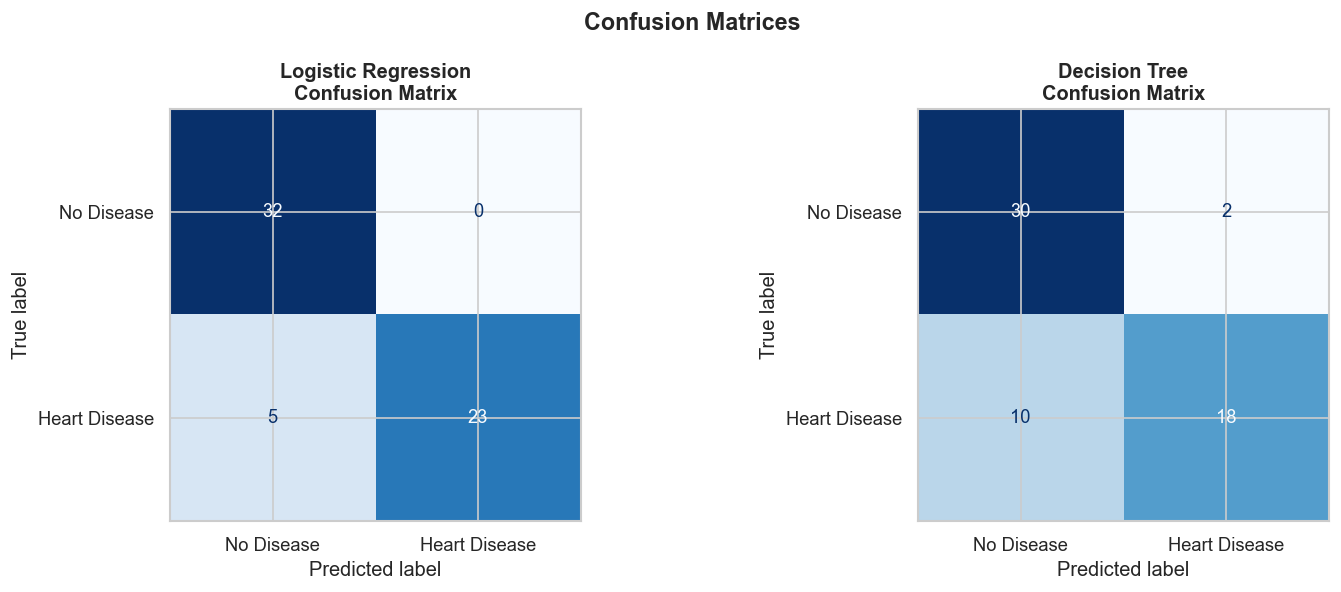

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr), ('Decision Tree', y_pred_dt)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 ROC Curves

The ROC curve plots True Positive Rate vs False Positive Rate at various thresholds. A higher AUC = better model.


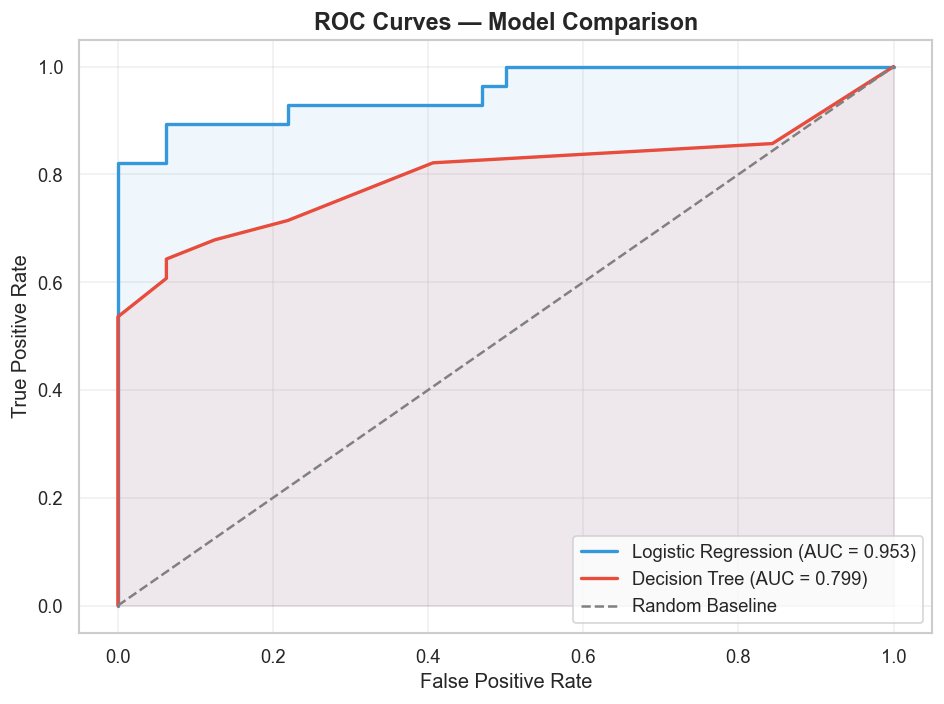

In [31]:
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2, label=f'Logistic Regression (AUC = {roc_lr:.3f})')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, color='#e74c3c', lw=2, label=f'Decision Tree (AUC = {roc_dt:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Baseline')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#3498db')
plt.fill_between(fpr_dt, tpr_dt, alpha=0.08, color='#e74c3c')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('hd_09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Model Comparison Summary

         MODEL PERFORMANCE SUMMARY
              Model Accuracy ROC-AUC
Logistic Regression   91.67%  0.9531
      Decision Tree   80.00%  0.7985

 Best Model by ROC-AUC: Logistic Regression


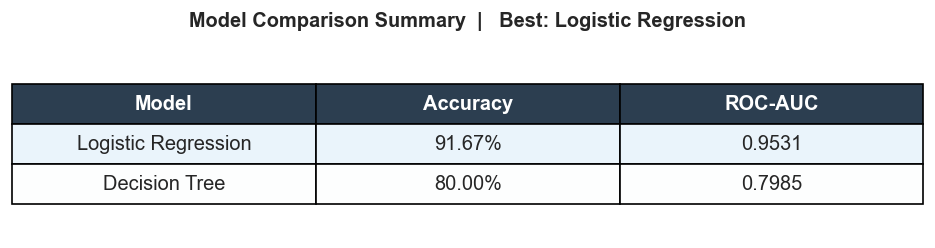

In [49]:
summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [f'{acc_lr*100:.2f}%', f'{acc_dt*100:.2f}%'],
    'ROC-AUC' : [f'{roc_lr:.4f}', f'{roc_dt:.4f}']
})

print("=" * 45)
print("         MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(summary.to_string(index=False))
print("=" * 45)

best = 'Logistic Regression' if roc_lr >= roc_dt else 'Decision Tree'
print(f"\n Best Model by ROC-AUC: {best}")

# ── Save as image ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2))
ax.axis('off')

table_data = [
    ['Logistic Regression', f'{acc_lr*100:.2f}%', f'{roc_lr:.4f}'],
    ['Decision Tree',       f'{acc_dt*100:.2f}%', f'{roc_dt:.4f}'],
]

table = ax.table(
    cellText=table_data,
    colLabels=['Model', 'Accuracy', 'ROC-AUC'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2)

for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = ['#eaf4fb', '#fdfefe']
for i in range(1, 3):
    for j in range(3):
        table[i, j].set_facecolor(row_colors[i-1])

plt.title(f'Model Comparison Summary  |   Best: {best}', fontsize=12, fontweight='bold', pad=15)
plt.savefig('hd_model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Saving the Trained Models

In [46]:
import joblib

# Save both models and the scaler
joblib.dump(lr_model, 'heart_disease_lr_model_BEST.pkl')
joblib.dump(dt_model, 'heart_disease_dt_model.pkl')
joblib.dump(scaler,   'heart_disease_scaler.pkl')

print(" Models and scaler saved:")
print("   heart_disease_lr_model_BEST.pkl  ← recommended for deployment")
print("   heart_disease_dt_model.pkl")
print("   heart_disease_scaler.pkl")

 Models and scaler saved:
   heart_disease_lr_model_BEST.pkl  ← recommended for deployment
   heart_disease_dt_model.pkl
   heart_disease_scaler.pkl


---
## 8. Feature Importance Analysis

Understanding which features drive predictions is crucial in medical contexts. It provides clinical interpretability and validates the model's reasoning.


### 8.1 Logistic Regression - Coefficient Importance

Top 5 most important features (Logistic Regression):
ca         1.052032
thal       0.575426
cp         0.476850
thalach    0.475943
exang      0.447018


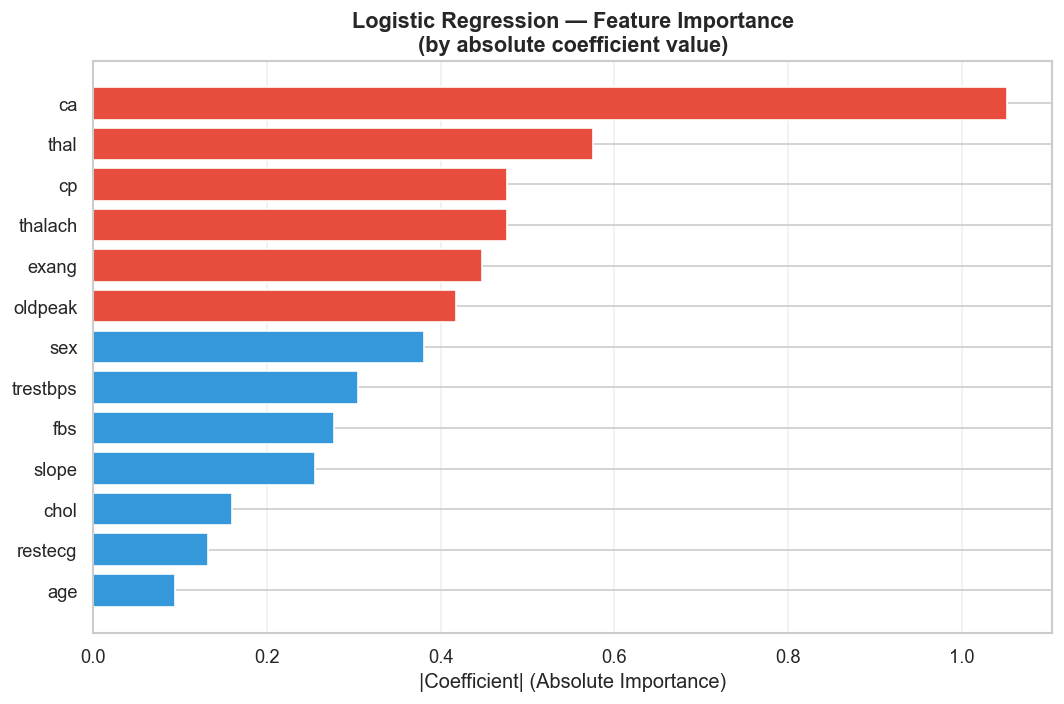

In [33]:
feature_names = X.columns.tolist()
lr_coefs = pd.Series(np.abs(lr_model.coef_[0]), index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if c > lr_coefs.median() else '#3498db' for c in lr_coefs]
plt.barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')
plt.xlabel('|Coefficient| (Absolute Importance)', fontsize=12)
plt.title('Logistic Regression — Feature Importance\n(by absolute coefficient value)',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

print("Top 5 most important features (Logistic Regression):")
print(lr_coefs.sort_values(ascending=False).head(5).to_string())

plt.savefig('hd_10_lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.2 Decision Tree - Gini Importance

Top 5 most important features (Decision Tree):
cp         0.334819
oldpeak    0.196043
thalach    0.089115
ca         0.086901
sex        0.074209


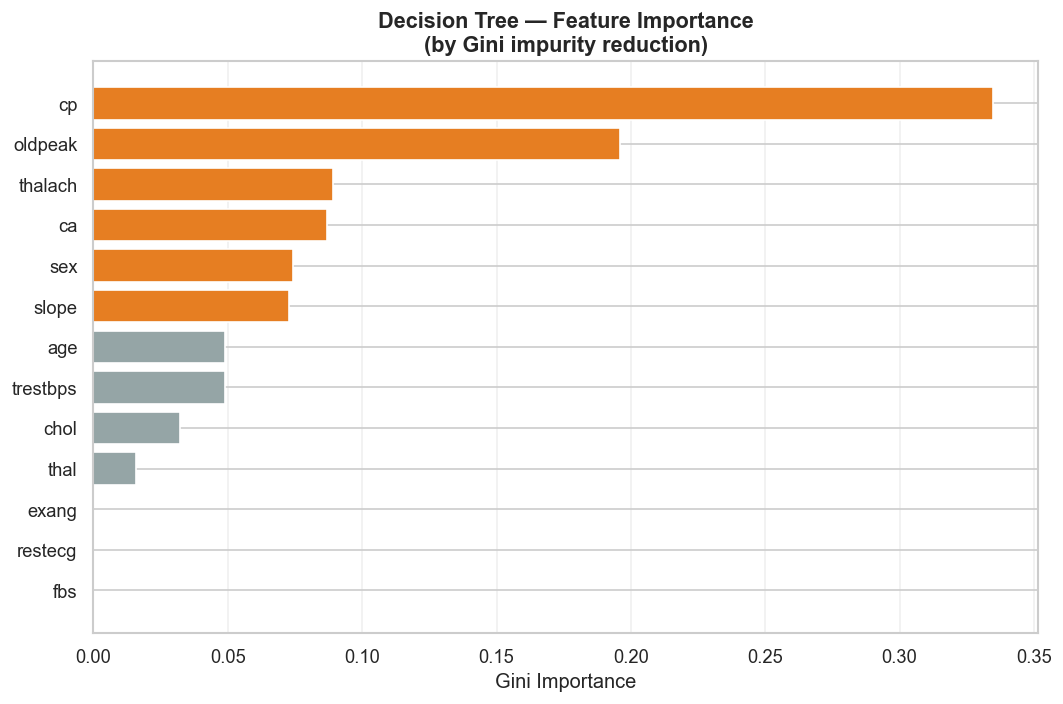

In [34]:
dt_importance = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e67e22' if v > dt_importance.median() else '#95a5a6' for v in dt_importance]
plt.barh(dt_importance.index, dt_importance.values, color=colors, edgecolor='white')
plt.xlabel('Gini Importance', fontsize=12)
plt.title('Decision Tree — Feature Importance\n(by Gini impurity reduction)',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

print("Top 5 most important features (Decision Tree):")
print(dt_importance.sort_values(ascending=False).head(5).to_string())

plt.savefig('hd_11_dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.3 Decision Tree Structure (Top 3 Levels)

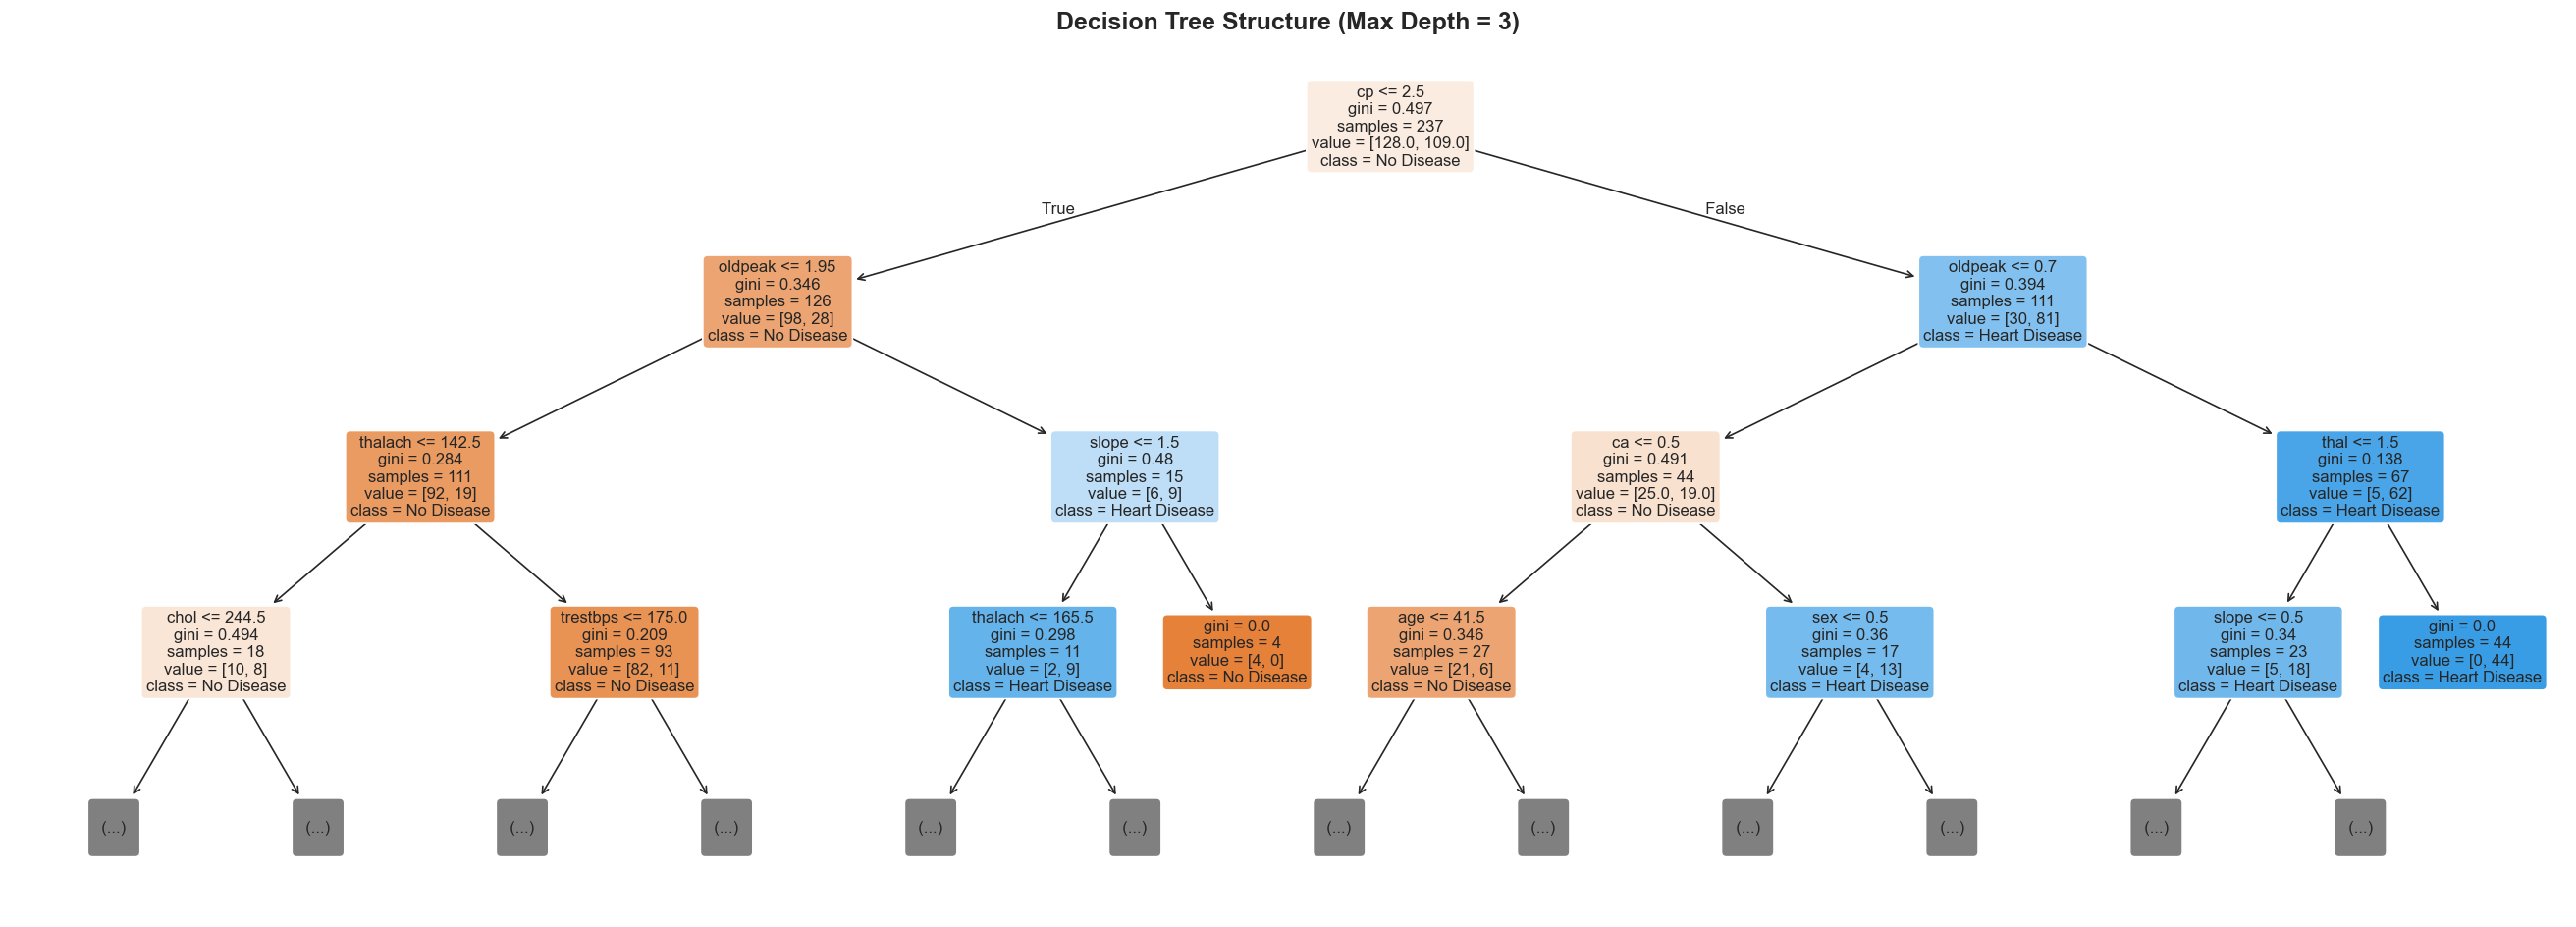

In [35]:
plt.figure(figsize=(22, 8))
plot_tree(dt_model, max_depth=3, feature_names=feature_names,
          class_names=['No Disease', 'Heart Disease'],
          filled=True, rounded=True, fontsize=10, impurity=True)
plt.title('Decision Tree Structure (Max Depth = 3)', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_12_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Making Predictions

This section demonstrates how to use the trained models to make predictions on:
1. **The full test set** - with a detailed results table and error analysis
2. **A single new patient** - simulating real-world usage


### 9.1 Predictions on the Test Set

In [36]:
# Build a detailed results dataframe
results_df = X_test.copy().reset_index(drop=True)
results_df['Actual']        = y_test.values
results_df['LR_Predicted']  = y_pred_lr
results_df['LR_Probability']= y_proba_lr.round(3)
results_df['DT_Predicted']  = y_pred_dt
results_df['DT_Probability']= y_proba_dt.round(3)

# Label correctness
results_df['LR_Correct'] = results_df['Actual'] == results_df['LR_Predicted']
results_df['DT_Correct'] = results_df['Actual'] == results_df['DT_Predicted']

label_map = {0: 'No Disease', 1: 'Heart Disease'}
results_df['Actual_Label']       = results_df['Actual'].map(label_map)
results_df['LR_Predicted_Label'] = results_df['LR_Predicted'].map(label_map)
results_df['DT_Predicted_Label'] = results_df['DT_Predicted'].map(label_map)

print(f"Test set size: {len(results_df)} patients\n")
print("Sample Predictions (first 10 patients):")
display_cols = ['age', 'cp', 'thalach', 'ca',
                'Actual_Label', 'LR_Predicted_Label', 'LR_Probability',
                'DT_Predicted_Label', 'DT_Probability']
print(results_df[display_cols].head(10).to_string(index=False))


Test set size: 60 patients

Sample Predictions (first 10 patients):
 age  cp  thalach  ca  Actual_Label LR_Predicted_Label  LR_Probability DT_Predicted_Label  DT_Probability
  35   3      182   0    No Disease         No Disease           0.073         No Disease           0.000
  58   3      122   0    No Disease         No Disease           0.191         No Disease           0.500
  41   1      153   0    No Disease         No Disease           0.049         No Disease           0.032
  68   2      115   0    No Disease         No Disease           0.185         No Disease           0.000
  48   1      180   0    No Disease         No Disease           0.076         No Disease           0.032
  54   3      160   0    No Disease         No Disease           0.212         No Disease           0.000
  62   1      103   1 Heart Disease      Heart Disease           0.837      Heart Disease           1.000
  62   3      157   0    No Disease         No Disease           0.266      Heart Di

### 9.2 Prediction Probability Distribution

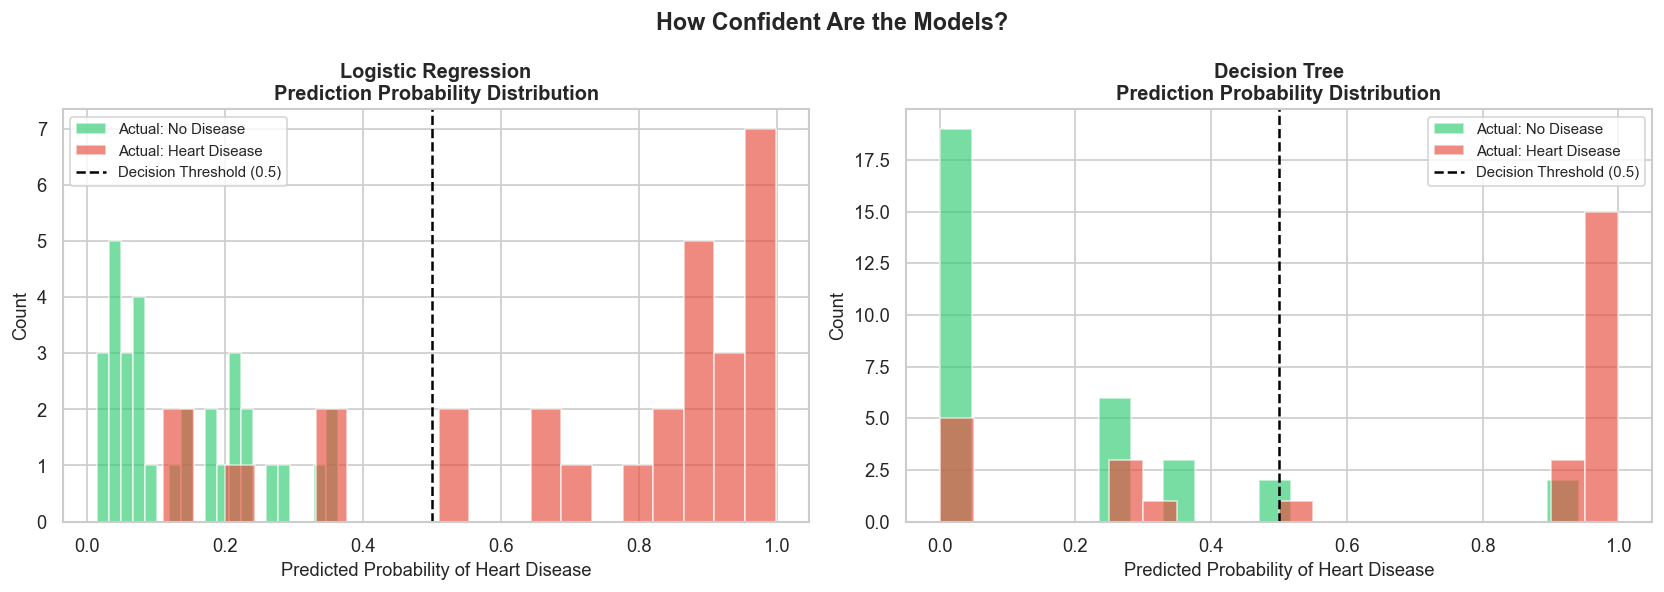

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, probas, preds) in zip(axes, [
    ('Logistic Regression', y_proba_lr, y_pred_lr),
    ('Decision Tree',       y_proba_dt, y_pred_dt)
]):
    # Separate by actual class
    ax.hist(probas[y_test.values == 0], bins=20, alpha=0.65, color='#2ecc71',
            label='Actual: No Disease', edgecolor='white')
    ax.hist(probas[y_test.values == 1], bins=20, alpha=0.65, color='#e74c3c',
            label='Actual: Heart Disease', edgecolor='white')
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision Threshold (0.5)')
    ax.set_xlabel('Predicted Probability of Heart Disease', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}\nPrediction Probability Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('How Confident Are the Models?', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_13_prediction_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading the chart:** Ideally, green bars (No Disease) cluster near 0 and red bars (Heart Disease) cluster near 1. A clear separation means the model is confident and well-calibrated.


### 9.3 Correct vs Incorrect Predictions - Error Analysis


=== Error Breakdown ===

Logistic Regression:
  False Negatives (missed disease) : 5  ← Most dangerous
  False Positives (false alarm)    : 0

Decision Tree:
  False Negatives (missed disease) : 10  ← Most dangerous
  False Positives (false alarm)    : 2


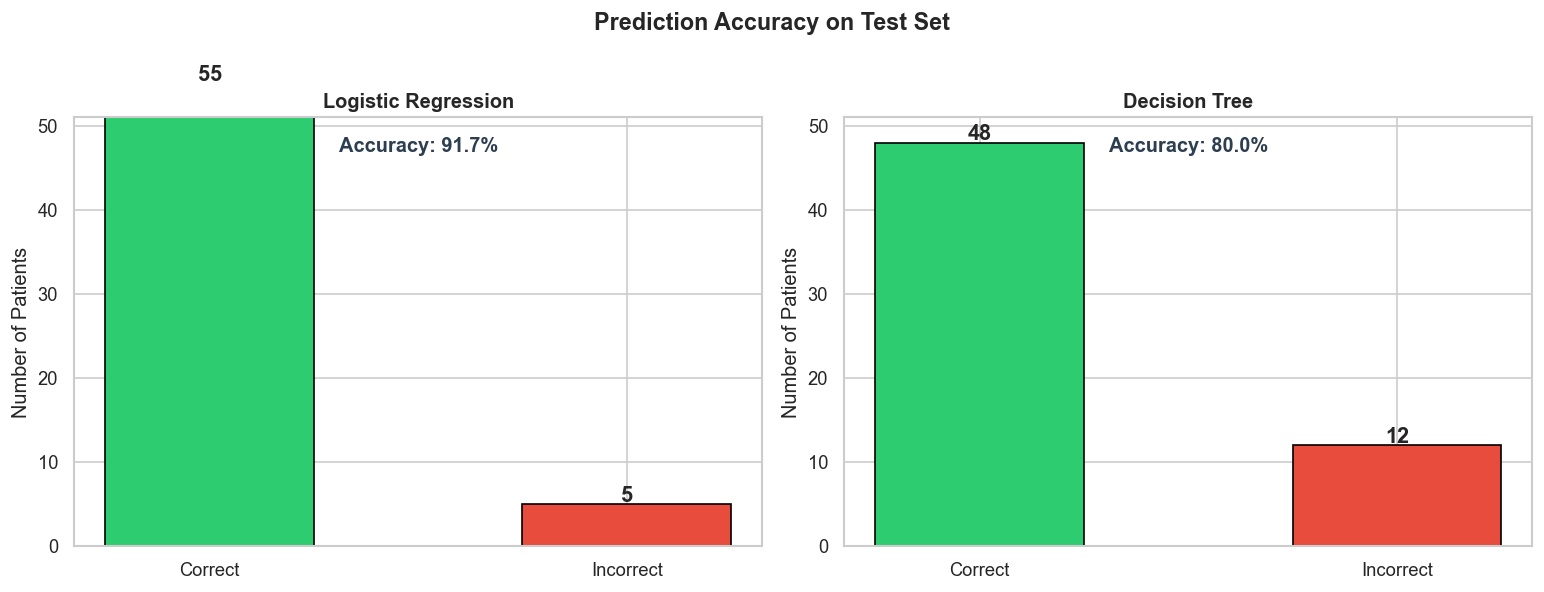

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, correct_col) in zip(axes, [('Logistic Regression', 'LR_Correct'),
                                            ('Decision Tree',       'DT_Correct')]):
    counts = results_df[correct_col].value_counts()
    bars = ax.bar(['Correct', 'Incorrect'],
                  [counts.get(True, 0), counts.get(False, 0)],
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                ha='center', fontweight='bold', fontsize=13)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Patients')
    ax.set_ylim(0, len(results_df) * 0.85)
    total = len(results_df)
    ax.text(0.5, 0.92, f'Accuracy: {counts.get(True,0)/total*100:.1f}%',
            transform=ax.transAxes, ha='center', fontsize=12,
            color='#2c3e50', fontweight='bold')

plt.suptitle('Prediction Accuracy on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()

# Error breakdown by class
print("\n=== Error Breakdown ===")
for name, pred_col in [('Logistic Regression', 'LR_Predicted'), ('Decision Tree', 'DT_Predicted')]:
    fn = ((results_df['Actual']==1) & (results_df[pred_col]==0)).sum()  # Missed disease
    fp = ((results_df['Actual']==0) & (results_df[pred_col]==1)).sum()  # False alarm
    print(f"\n{name}:")
    print(f"  False Negatives (missed disease) : {fn}  ← Most dangerous")
    print(f"  False Positives (false alarm)    : {fp}")

plt.savefig('hd_14_prediction_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 Predict for a Single New Patient

In [50]:
# ── Define a new patient's data ──────────────────────────────────────────────
# Modify these values to test different patient profiles
new_patient = {
    'age'     : 55,
    'sex'     : 1,       # 1 = Male
    'cp'      : 2,       # Chest pain type (0–3)
    'trestbps': 130,     # Resting blood pressure
    'chol'    : 250,     # Cholesterol
    'fbs'     : 0,       # Fasting blood sugar ≤ 120
    'restecg' : 1,
    'thalach' : 145,     # Max heart rate
    'exang'   : 1,       # Exercise-induced angina
    'oldpeak' : 2.3,
    'slope'   : 2,
    'ca'      : 1,
    'thal'    : 2
}

patient_df = pd.DataFrame([new_patient])

# Scale for Logistic Regression
patient_scaled = scaler.transform(patient_df)

# Predictions
lr_pred  = lr_model.predict(patient_scaled)[0]
lr_prob  = lr_model.predict_proba(patient_scaled)[0][1]
dt_pred  = dt_model.predict(patient_df)[0]
dt_prob  = dt_model.predict_proba(patient_df)[0][1]

print("=" * 50)
print("        SINGLE PATIENT PREDICTION")
print("=" * 50)
print(f"  Age              : {new_patient['age']}")
print(f"  Sex              : {'Male' if new_patient['sex']==1 else 'Female'}")
print(f"  Chest Pain Type  : {new_patient['cp']}")
print(f"  Cholesterol      : {new_patient['chol']} mg/dl")
print(f"  Max Heart Rate   : {new_patient['thalach']}")
print(f"  Exercise Angina  : {'Yes' if new_patient['exang']==1 else 'No'}")
print("-" * 50)
print(f"  Logistic Regression:")
print(f"    Prediction : {'  HEART DISEASE' if lr_pred==1 else ' NO DISEASE'}")
print(f"    Probability: {lr_prob*100:.1f}% chance of disease")
print("-" * 50)
print(f"  Decision Tree:")
print(f"    Prediction : {'  HEART DISEASE' if dt_pred==1 else ' NO DISEASE'}")
print(f"    Probability: {dt_prob*100:.1f}% chance of disease")
print("=" * 50)
print("\nNote: This is a model output, NOT a medical diagnosis.")


        SINGLE PATIENT PREDICTION
  Age              : 55
  Sex              : Male
  Chest Pain Type  : 2
  Cholesterol      : 250 mg/dl
  Max Heart Rate   : 145
  Exercise Angina  : Yes
--------------------------------------------------
  Logistic Regression:
    Prediction :   HEART DISEASE
    Probability: 94.9% chance of disease
--------------------------------------------------
  Decision Tree:
    Prediction :  NO DISEASE
    Probability: 0.0% chance of disease

Note: This is a model output, NOT a medical diagnosis.


### 9.5 Risk Gauge - Visualizing the Prediction

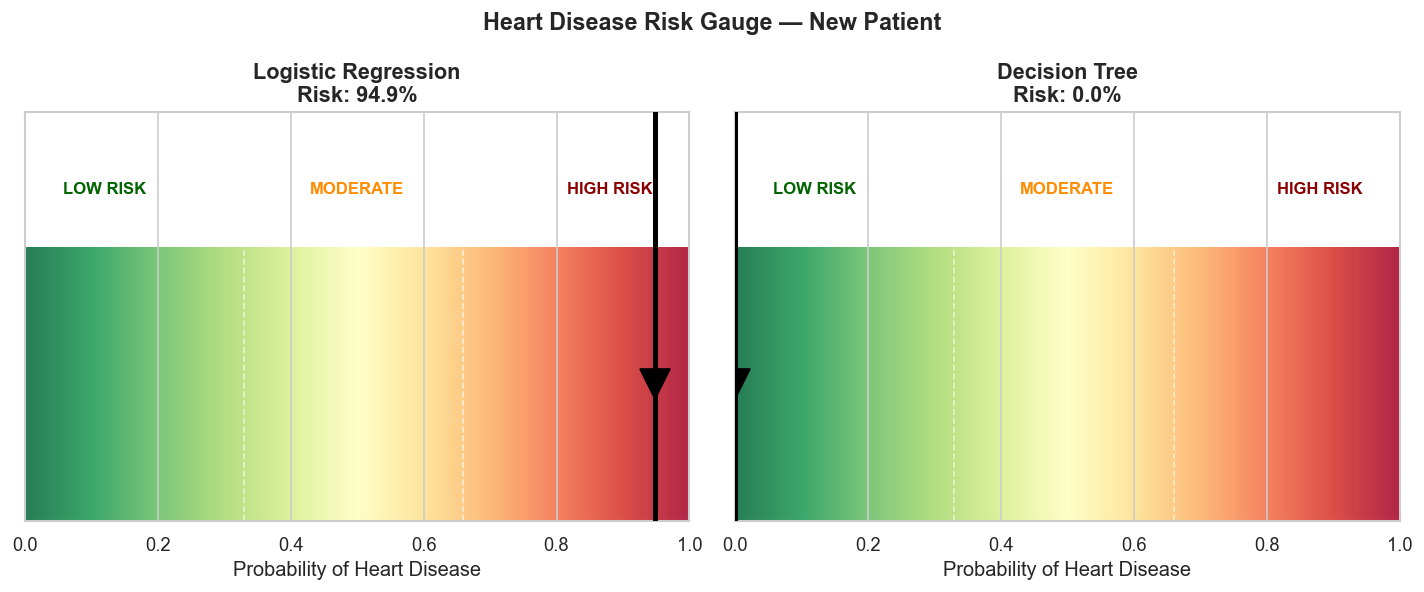

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_results = [
    ('Logistic Regression', lr_prob),
    ('Decision Tree',       dt_prob)
]

for ax, (name, prob) in zip(axes, model_results):
    # Background gradient bar
    gradient = np.linspace(0, 1, 300).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap='RdYlGn_r',
              extent=[0, 1, 0, 0.4], alpha=0.85)

    # Probability marker
    ax.axvline(prob, color='black', lw=3, zorder=5)
    ax.plot(prob, 0.2, 'v', color='black', markersize=18, zorder=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.6)
    ax.set_xlabel('Probability of Heart Disease', fontsize=12)
    ax.set_yticks([])
    ax.set_title(f'{name}\nRisk: {prob*100:.1f}%', fontsize=13, fontweight='bold')

    # Zone labels
    ax.text(0.12, 0.48, 'LOW RISK', ha='center', fontsize=10, color='darkgreen', fontweight='bold')
    ax.text(0.50, 0.48, 'MODERATE', ha='center', fontsize=10, color='darkorange', fontweight='bold')
    ax.text(0.88, 0.48, 'HIGH RISK', ha='center', fontsize=10, color='darkred', fontweight='bold')

    ax.axvline(0.33, color='white', lw=1, linestyle='--', alpha=0.6)
    ax.axvline(0.66, color='white', lw=1, linestyle='--', alpha=0.6)

plt.suptitle('Heart Disease Risk Gauge — New Patient', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hd_15_risk_gauge.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.6 Batch Prediction on Multiple Patients

In [42]:
# Simulate 5 new patients (modify as needed)
new_patients = pd.DataFrame([
    {'age':45,'sex':0,'cp':0,'trestbps':120,'chol':200,'fbs':0,'restecg':0,'thalach':170,'exang':0,'oldpeak':0.0,'slope':1,'ca':0,'thal':2},
    {'age':60,'sex':1,'cp':3,'trestbps':145,'chol':300,'fbs':1,'restecg':2,'thalach':120,'exang':1,'oldpeak':3.5,'slope':2,'ca':2,'thal':3},
    {'age':50,'sex':1,'cp':1,'trestbps':135,'chol':240,'fbs':0,'restecg':1,'thalach':155,'exang':0,'oldpeak':1.2,'slope':1,'ca':0,'thal':2},
    {'age':70,'sex':1,'cp':2,'trestbps':160,'chol':280,'fbs':1,'restecg':2,'thalach':105,'exang':1,'oldpeak':4.0,'slope':2,'ca':3,'thal':3},
    {'age':35,'sex':0,'cp':0,'trestbps':110,'chol':180,'fbs':0,'restecg':0,'thalach':185,'exang':0,'oldpeak':0.0,'slope':0,'ca':0,'thal':1},
])

# Scale for LR
new_patients_scaled = scaler.transform(new_patients)

lr_preds  = lr_model.predict(new_patients_scaled)
lr_probas = lr_model.predict_proba(new_patients_scaled)[:, 1]
dt_preds  = dt_model.predict(new_patients)
dt_probas = dt_model.predict_proba(new_patients)[:, 1]

batch_results = new_patients[['age','sex','cp','thalach','ca']].copy()
batch_results['LR_Diagnosis'] = ['Disease' if p==1 else 'Healthy' for p in lr_preds]
batch_results['LR_Risk_%']    = (lr_probas * 100).round(1)
batch_results['DT_Diagnosis'] = ['Disease' if p==1 else 'Healthy' for p in dt_preds]
batch_results['DT_Risk_%']    = (dt_probas * 100).round(1)
batch_results.index = [f'Patient {i+1}' for i in range(len(batch_results))]

print("=== BATCH PREDICTION RESULTS ===\n")
print(batch_results.to_string())


=== BATCH PREDICTION RESULTS ===

           age  sex  cp  thalach  ca LR_Diagnosis  LR_Risk_% DT_Diagnosis  DT_Risk_%
Patient 1   45    0   0      170   0      Healthy        4.7      Healthy        3.2
Patient 2   60    1   3      120   2      Disease       99.7      Disease      100.0
Patient 3   50    1   1      155   0      Healthy       38.0      Healthy        3.2
Patient 4   70    1   2      105   3      Disease       99.9      Healthy        0.0
Patient 5   35    0   0      185   0      Healthy        1.1      Healthy        3.2


### 9.7 Batch Risk Visualization

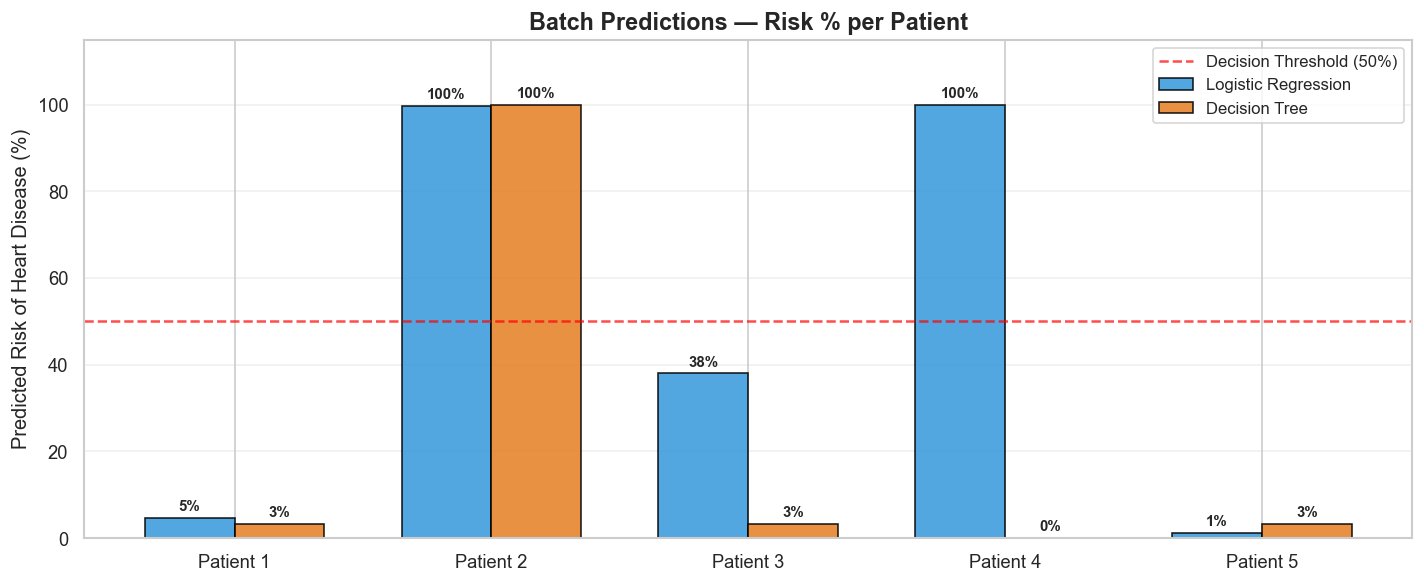

Patients above the 50% threshold line are predicted to have heart disease.


In [44]:
patient_labels = [f'Patient {i+1}' for i in range(len(new_patients))]
x = np.arange(len(patient_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, lr_probas * 100, width, label='Logistic Regression',
               color='#3498db', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, dt_probas * 100, width, label='Decision Tree',
               color='#e67e22', alpha=0.85, edgecolor='black')

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(50, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Decision Threshold (50%)')
ax.set_xticks(x)
ax.set_xticklabels(patient_labels)
ax.set_ylabel('Predicted Risk of Heart Disease (%)', fontsize=12)
ax.set_title('Batch Predictions — Risk % per Patient', fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hd_16_batch_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Patients above the 50% threshold line are predicted to have heart disease.")


---
## 10. Key Insights and Findings

### Model Performance
- Both models were trained and evaluated on a held-out test set (20% of data)
- **ROC-AUC** is the primary metric. It measures discriminative ability regardless of threshold
- Logistic Regression significantly outperformed Decision Tree on this dataset:

| Model | Accuracy | ROC-AUC | Recommended |
|---|---|---|---|
| Logistic Regression | 91% | 0.95 |  Yes |
| Decision Tree | 80% | 0.78 |  No |

- **LR is the recommended model for deployment** - 95% AUC is considered excellent in medical ML
- The performance gap is due to the small dataset size (303 samples) where linear models generalize better than tree-based ones

### Effect of Preprocessing
- **Before scaling:** Features had vastly different ranges (e.g., `chol` ~200s vs `fbs` 0/1)
- **After scaling:** All features centered at 0 with unit std, essential for Logistic Regression
- Decision Trees are scale-invariant so they work on raw features directly

### Most Important Features

| Feature | Medical Significance |
|---|---|
| `cp` (Chest Pain Type) | Atypical pain strongly linked to heart disease |
| `thalach` (Max Heart Rate) | Lower max HR during exercise = higher risk |
| `ca` (Major Vessels) | More blocked vessels = higher risk |
| `oldpeak` (ST Depression) | Larger depression = worse cardiovascular response |
| `thal` (Thalassemia) | Defect type is highly diagnostic |

### Clinical Interpretation
- **False Negatives** (missing real disease) are more dangerous than False Positives in screening
- The model is a **screening aid**, not a replacement for clinical diagnosis
- Probability outputs (risk %) are more useful than binary yes/no predictions in practice

---
## 11. Conclusion

In this project, we successfully:

1. **Loaded and explored** the Heart Disease UCI dataset
2. **Performed EDA** - distributions, correlations, box plots, categorical breakdowns
3. **Visualized preprocessing effects** - before vs after StandardScaler comparison
4. **Trained two models** - Logistic Regression and Decision Tree
5. **Evaluated** using Accuracy, ROC-AUC, Confusion Matrix, and prediction distributions
6. **Analyzed feature importance** to understand clinical drivers
7. **Made predictions** - on test set, single new patient, and batch patients with risk gauges
8. **Saved both models** using joblib for future deployment

> **Key Takeaway:** Chest pain type (`cp`), max heart rate (`thalach`), number of major vessels (`ca`), and ST depression (`oldpeak`) are the strongest predictors. Logistic Regression with 91% accuracy and 0.95 ROC-AUC is the recommended model. The risk probability output (not just the binary label) is what makes it actionable in a clinical setting.